# Random Forest

## Who did you work with? (4 members total)
1. Sabeeh
2. Ronish
3. Arihaan
4. Nihal

## Attribution
Please supply all citations that you used to complete this assignment. They should be in APA format.


1.   Citation here.
2.   and here.
3.   and here....

##Cited
<cite>
Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions, Statistics and Probability Letters, 33 (1997) 291-297

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


</cite>

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn import tree
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics
import sklearn.metrics
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot
import graphviz
from sklearn.datasets import fetch_california_housing

## Calculate Weighted Gini

Left Gini: 0.5
Right Gini: 0.5
Weighted Gini: 0.5


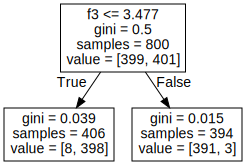

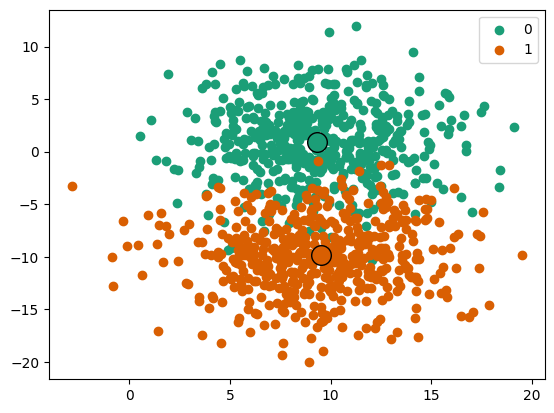

In [3]:
# Generate data
X, y, centers = make_blobs(n_samples=1000, centers=2, n_features=6, cluster_std=3.5, return_centers=True, random_state=4)

df = np.column_stack((X, y))
df = pd.DataFrame(df, columns=["f1","f2","f3","f4","f5","f6","target"])

# Plot
for i in range(len(np.unique(y))):
  x0 = df[df["target"]==i]["f1"]
  y0 = df[df["target"]==i]["f2"]
  label = df[df["target"]==i]["target"]
  colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
  plt.scatter(x0,y0,label = i, c=colors[i])
  plt.scatter(centers[i][0],centers[i][1], c=colors[i], s=200, edgecolors='black', linewidths=1)

plt.legend()
# plt.show()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=887)

def gini_impurity(labels):
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return 1 - np.sum(probs ** 2)

# Use a simple split on feature f1
threshold = np.median(X[:, 0])

left_mask = X[:, 0] <= threshold
right_mask = X[:, 0] > threshold

y_left = y[left_mask]
y_right = y[right_mask]

gini_left = gini_impurity(y_left)
gini_right = gini_impurity(y_right)

weighted_gini = (
    (len(y_left) / len(y)) * gini_left +
    (len(y_right) / len(y)) * gini_right
)

print("Left Gini:", gini_left)
print("Right Gini:", gini_right)
print("Weighted Gini:", weighted_gini)

# Decision Tree
clf = DecisionTreeClassifier(criterion='gini', random_state=887, max_depth=1)
clf.fit(X_train, y_train)

dot_data = tree.export_graphviz(
    clf,
    out_file=None,
    feature_names=["f1","f2","f3","f4","f5","f6"]
)

graph = graphviz.Source(dot_data)
graph

### Answer here:

The weighted Gini was calculated by splitting the dataset into two subsets using a threshold and computing the Gini impurity for each subset, then combining them using a weighted average based on the number of samples. In this case, splitting on the median of f1 resulted in both subsets having equal class distributions, making Left Gini = 0.5, Right Gini = 0.5, and a Weighted Gini = 0.5, indicating no improvement in purity. However, the decision tree instead selected a split on feature f3 <= 3.477, which produced much lower Gini values (0.039 and 0.015), showing a far more effective separation of the two classes. This highlights that the tree’s chosen split significantly improves classification compared to the manual split.

In [5]:
# Split probabilities
prob_of_True = 406 / 800
prob_of_False = 394 / 800

# Left class proportions
left_p1 = 8 / 406
left_p2 = 398 / 406

# Right lass proportions
right_p1 = 391 / 394
right_p2 = 3 / 394

# Gini calculations
gini_Left = 1 - (left_p1**2 + left_p2**2)
gini_Right = 1 - (right_p1**2 + right_p2**2)

# Weighted Gini
weighted_gini = prob_of_True * gini_Left + prob_of_False * gini_Right

# Purity improvement
purity_improvement = 0.5 - weighted_gini

print(f"Gini Left: {gini_Left}")
print(f"Gini Right: {gini_Right}")
print(f"Weighted Gini: {weighted_gini}")
print(f"Purity Improvement: {purity_improvement}")

Gini Left: 0.03863233759615614
Gini Right: 0.015112473910690705
Weighted Gini: 0.02704880473106441
Purity Improvement: 0.4729511952689356


## Data Set


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df = pd.read_csv('/content/drive/MyDrive/IQVIAData.csv')


In [8]:
#Loading the dataset


import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/IQVIAData.csv')

df.columns = df.columns.str.strip()

# Function to convert $ values
def convert_money(val):
    if pd.isna(val):
        return np.nan

    val = str(val).replace("$", "").strip()

    # special cases
    val = val.replace(".M", "M").replace(".B", "B").replace(".K", "K")

    if "B" in val:
        return float(val.replace("B", "")) * 1e9
    elif "M" in val:
        return float(val.replace("M", "")) * 1e6
    elif "K" in val:
        return float(val.replace("K", "")) * 1e3      ##change K = 1000
    else:
        return float(val)

# Apply conversion to all columns except month and target
for col in df.columns:
    if col not in ["Month", "TLC"]:  # assuming TLC is label column
        df[col] = df[col].apply(convert_money)

# Fix Month column
df["Month"] = pd.to_datetime(df["Month"], format="%b-%y")
df["year"] = df["Month"].dt.year
df["month"] = df["Month"].dt.month

# Drop original Month column
df = df.drop(columns=["Month"])


In [9]:
df = df.dropna()

In [10]:
print(df.dtypes)
print(df.head())

CHAIN STORES            float64
CLINICS                 float64
FEDERAL FACILITIES      float64
FOOD STORES             float64
HMO                     float64
HOME HEALTH CARE        float64
INDEPENDENT             float64
LONG-TERM CARE          float64
MAIL                    float64
MISC - OTHER            float64
MISC - PRISONS          float64
MISC - UNIVERSITIES     float64
NON-FEDERAL HOSPITAL    float64
TLC                      object
year                      int32
month                     int32
dtype: object
   CHAIN STORES       CLINICS  FEDERAL FACILITIES   FOOD STORES         HMO  \
0  7.900000e+09  1.400000e+09         111700000.0  1.400000e+09  69700000.0   
1  5.600000e+09  9.524000e+08          93600000.0  9.998000e+08  49500000.0   
2  5.400000e+09  9.364000e+08          70900000.0  8.991000e+08  42400000.0   
3  7.000000e+09  1.300000e+09         100200000.0  1.200000e+09  54200000.0   
4  5.600000e+09  9.746000e+08          81500000.0  9.785000e+08  45700000.0   


### Items Updates

* Split date to month, year
* Change K = 1000, M = 1000000, etc.


## Create the Random Forest Tree

Create the random forest tree for this data, and produce one of the decision trees.

In [ ]:
## Code here

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["TLC"] = le.fit_transform(df["TLC"])

In [18]:
X = df.drop("TLC", axis=1)
y = df["TLC"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


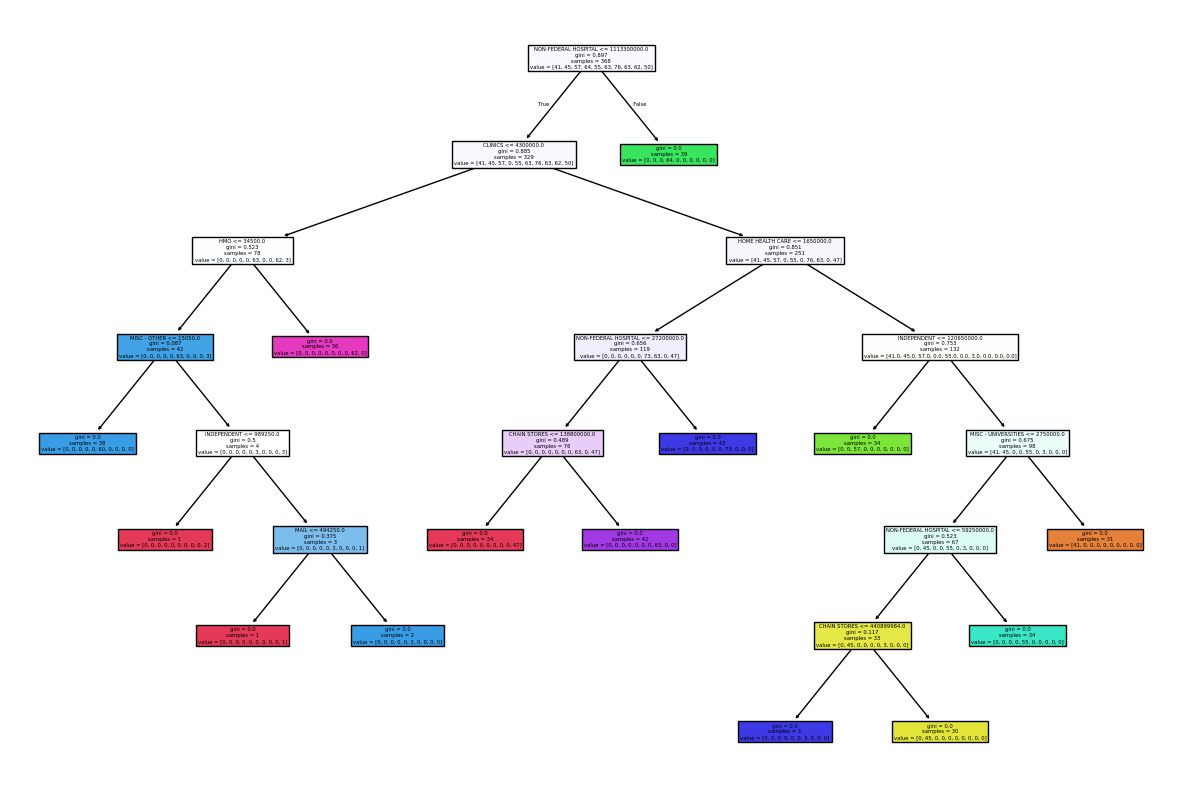

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(
    rf.estimators_[0],   # one tree from the forest
    feature_names=X.columns,
    filled=True
)
plt.show()

## Feature Importances - Mean Decrease in Impurity & Permutation on Full Model

Create both the Mean Decrease in Impurity & Permutation on Full Model for this data.

Discuss the differences between these two approaches.

In [ ]:
## Code here

In [22]:
import pandas as pd

mdi_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("MDI Feature Importance:\n", mdi_importance)

MDI Feature Importance:
 NON-FEDERAL HOSPITAL    0.110007
MISC - OTHER            0.092600
INDEPENDENT             0.091450
FOOD STORES             0.089967
CLINICS                 0.087097
MISC - UNIVERSITIES     0.086251
LONG-TERM CARE          0.078260
HMO                     0.073464
MISC - PRISONS          0.069914
MAIL                    0.066294
HOME HEALTH CARE        0.064010
CHAIN STORES            0.060355
FEDERAL FACILITIES      0.029634
year                    0.000542
month                   0.000156
dtype: float64


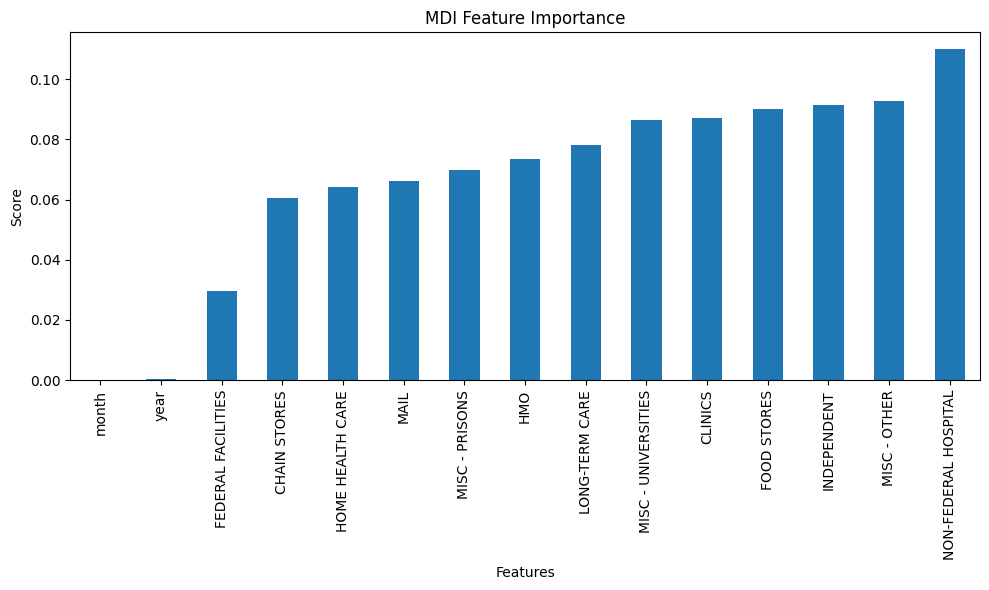

In [27]:
# Plot MDI
plt.figure(figsize=(10, 6))
mdi_importance.sort_values().plot(kind='bar')
plt.title("MDI Feature Importance")
plt.ylabel("Score")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=2
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("Permutation Importance:\n", perm_importance)

Permutation Importance:
 MAIL                    0.004167
MISC - OTHER            0.000694
CHAIN STORES            0.000000
FOOD STORES             0.000000
HMO                     0.000000
CLINICS                 0.000000
FEDERAL FACILITIES      0.000000
INDEPENDENT             0.000000
HOME HEALTH CARE        0.000000
LONG-TERM CARE          0.000000
MISC - PRISONS          0.000000
MISC - UNIVERSITIES     0.000000
NON-FEDERAL HOSPITAL    0.000000
year                    0.000000
month                   0.000000
dtype: float64


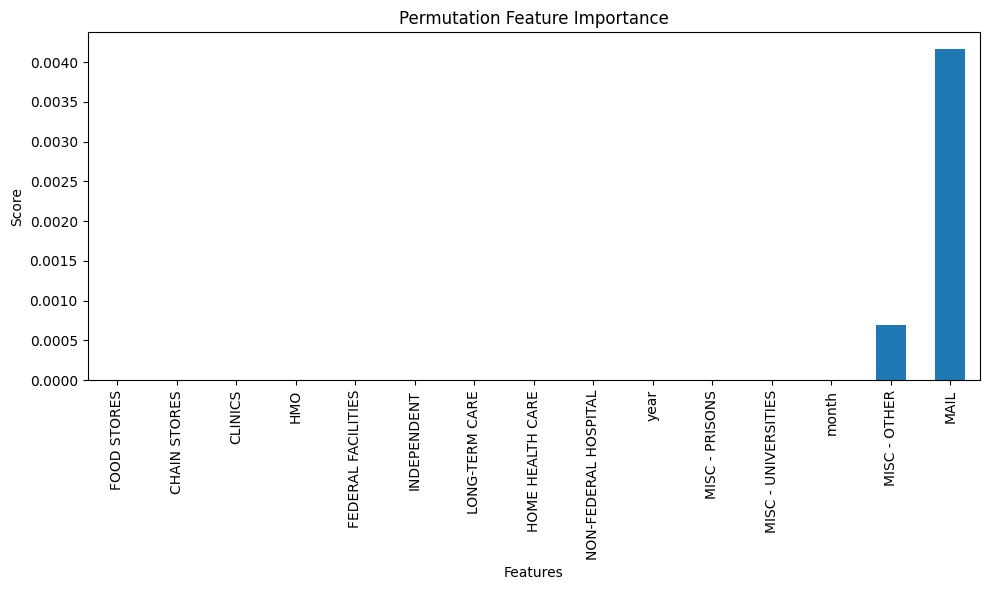

In [31]:
# Plot Permutation
plt.figure(figsize=(10, 6))
perm_importance.sort_values().plot(kind='bar')

plt.title("Permutation Feature Importance")
plt.ylabel("Score")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

The mean decrease in impurity (MDI) measures feature importance based on how much each feature reduces Gini impurity across the trees. Features like NON-FEDERAL HOSPITAL (0.110007), MISC - OTHER (0.092600), and INDEPENDENT (0.091450) appear most important because they are frequently used in splits that reduce impurity.

However, permutation importance tells a different story. When features are randomly shuffled, only MAIL (0.004167) and slightly MISC - OTHER show any impact on model performance, while all other features have almost no importance. This indicates that shuffling most features does not significantly reduce accuracy.

This suggests that although many features are used in tree splits (high MDI), they may not actually contribute meaningful predictive power. MDI can overestimate importance because it is biased toward features that are frequently split on, even if those splits do not strongly impact performance.

Permutation importance is generally more reliable because it evaluates how much each feature affects model performance on unseen data. In this case, the near-zero permutation scores suggest the model may not be strongly predictive, or that many features are redundant or weakly related to the target.